## Train A Test A

### Classification

Category distribution:
4    6214
0    5219
3     254
2     112
5      38
6      32
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.63      0.69      0.66      1010
      Button       0.88      0.78      0.82         9
        Door       0.77      0.74      0.76        23
      Motion       0.88      0.48      0.62        48
      Socket       0.74      0.70      0.72      1277
 Temperature       0.71      0.56      0.62         9
   Vibration       0.50      0.25      0.33         4

    accuracy                           0.69      2380
   macro avg       0.73      0.60      0.65      2380
weighted avg       0.70      0.69      0.69      2380

Macro F1-Score: 0.6478


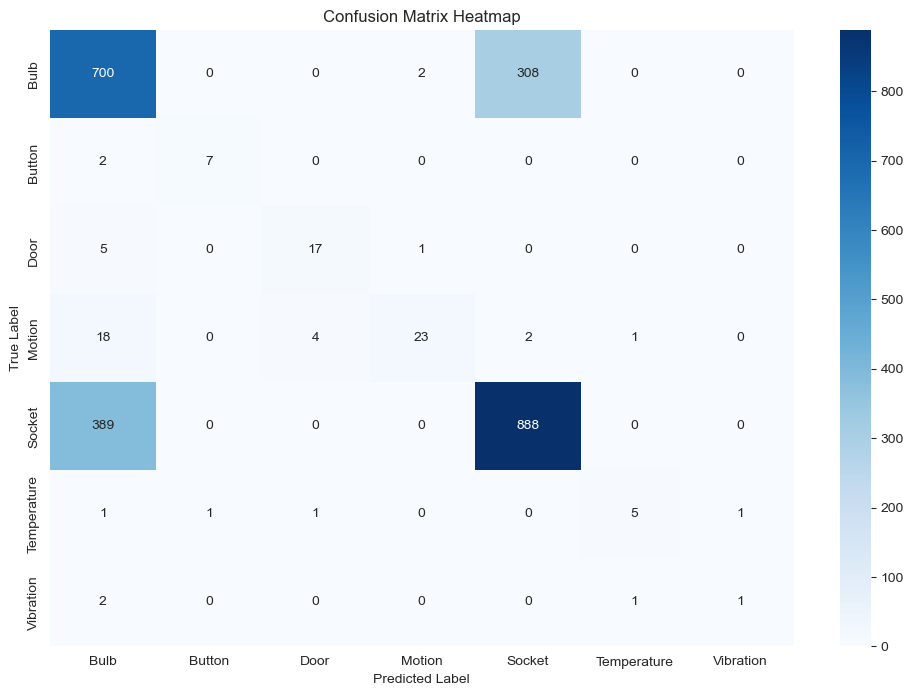

In [2]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    1689
14    1362
5     1355
13    1293
12    1157
8     1156
6     1041
9      852
7      829
10     699
11     182
1       40
20      38
2       34
4       32
3       31
0       30
19      24
16      23
18      17
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      1.00      1.00         9
        Aqara Door 1       0.33      0.30      0.32        10
        Aqara Door 2       0.43      0.33      0.38         9
        Aqara Motion       0.67      0.67      0.67         6
     Aqara Vibration       0.50      0.25      0.33         4
       Ledvance Bulb       0.31      0.36      0.33       253
Ledvance Smart+ Plug       0.30      0.28      0.29       214
    Ledvance Z3 Plug       0.25      0.25      0.25       160
           Moes Bulb       0.74      0.84      0.79       236
      Philips Lamp 1       0.15      0.14      0.15       160
      Philips Lamp 2       0.21      

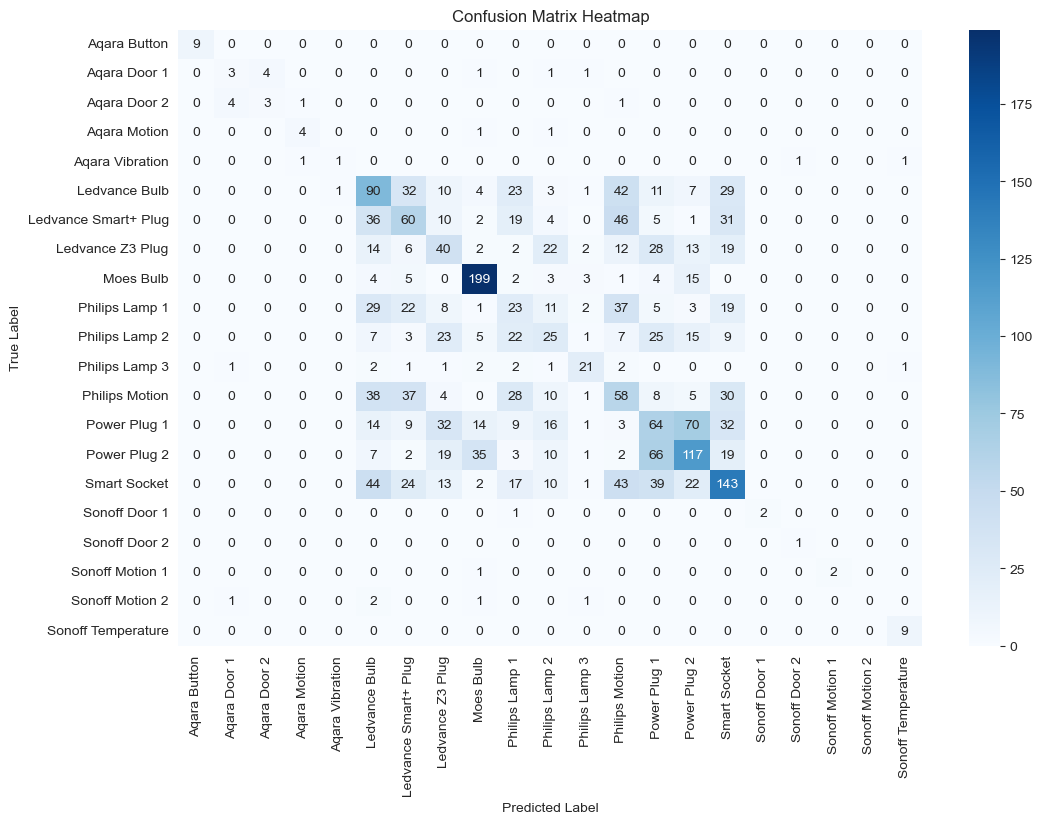

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    9078
0    6647
3     611
2     196
5     110
1     100
6      41
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.63      0.65      0.64      1343
      Button       0.67      0.38      0.49        26
        Door       0.70      0.88      0.78        32
      Motion       0.77      0.76      0.77       133
      Socket       0.73      0.72      0.72      1796
 Temperature       0.73      0.38      0.50        21
   Vibration       0.25      0.33      0.29         6

    accuracy                           0.69      3357
   macro avg       0.64      0.59      0.60      3357
weighted avg       0.69      0.69      0.69      3357

Macro F1-Score: 0.5971


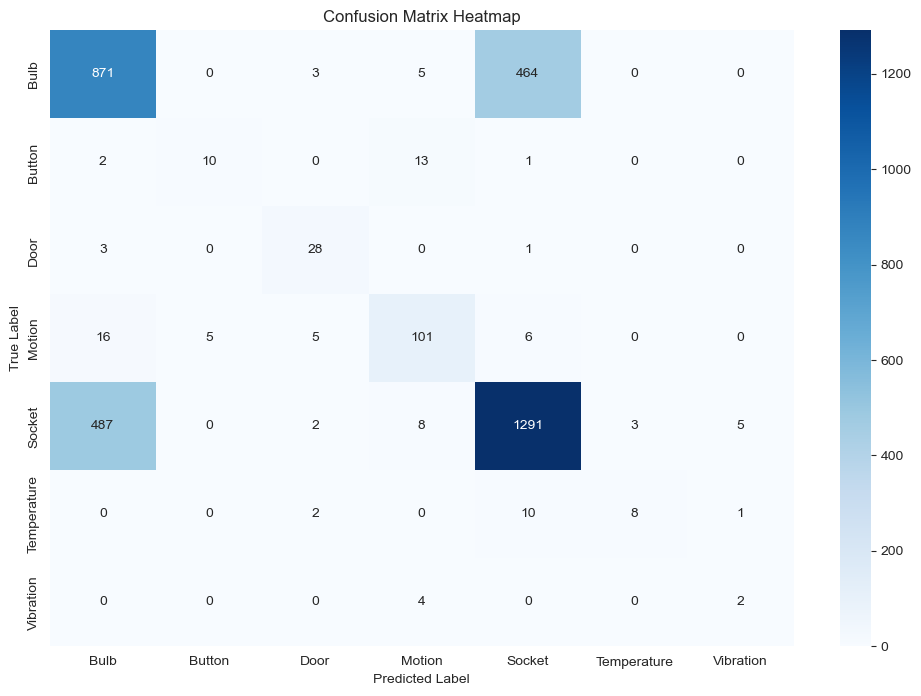

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    2791
13    2636
5     1788
8     1510
14    1408
7     1342
9     1311
11    1280
6      901
10     758
12     415
3      119
20     110
0      100
16      59
18      56
1       53
17      53
4       41
2       31
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.70      0.54      0.61        26
        Aqara Door 1       0.50      0.71      0.59         7
        Aqara Door 2       0.71      0.71      0.71         7
        Aqara Motion       0.82      0.78      0.80        23
     Aqara Vibration       0.29      0.33      0.31         6
       Ledvance Bulb       0.30      0.30      0.30       366
Ledvance Smart+ Plug       0.14      0.12      0.13       200
    Ledvance Z3 Plug       0.13      0.12      0.13       271
           Moes Bulb       0.52      0.61      0.56       291
      Philips Lamp 1       0.32      0.30      0.31       283
      Philips Lamp 2       0.15      

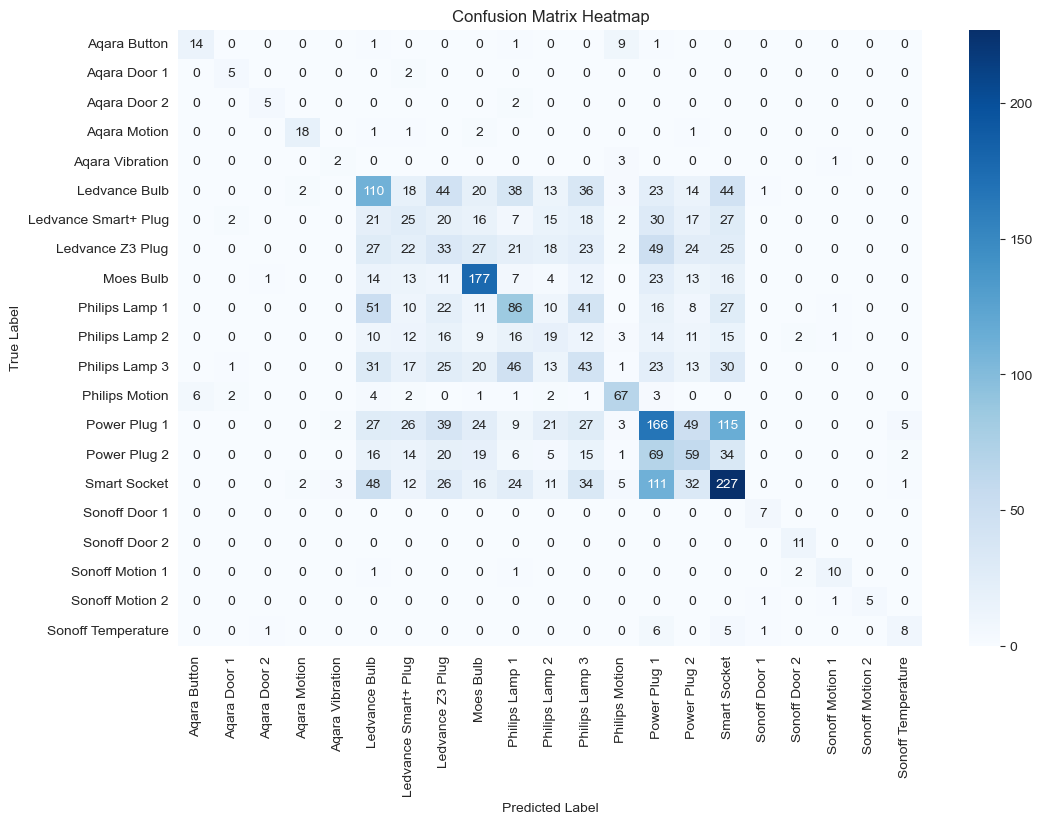

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    6214
0    5219
3     254
2     112
5      38
6      32
1      30
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.53      0.54      0.54      6647
      Button       0.00      0.00      0.00       100
        Door       0.28      0.10      0.14       196
      Motion       0.53      0.48      0.50       611
      Socket       0.67      0.68      0.68      9078
 Temperature       0.35      0.17      0.23       110
   Vibration       0.00      0.00      0.00        41

    accuracy                           0.60     16783
   macro avg       0.34      0.28      0.30     16783
weighted avg       0.60      0.60      0.60     16783

Macro F1-Score: 0.2987


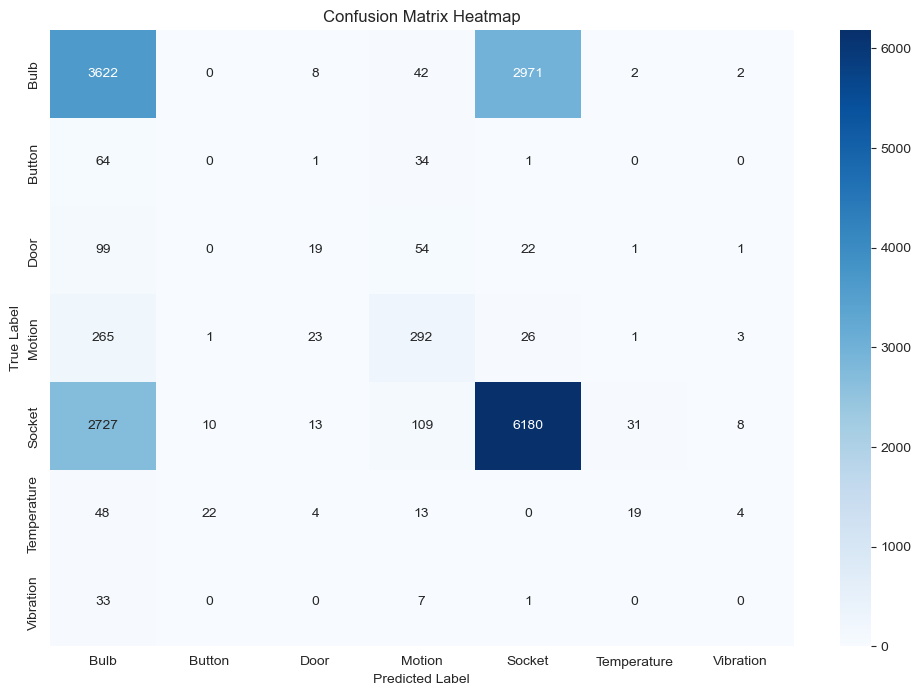

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    1689
14    1362
5     1355
13    1293
12    1157
8     1156
6     1041
9      852
7      829
10     699
11     182
1       40
20      38
2       34
4       32
3       31
0       30
19      24
16      23
18      17
17      15
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.02      0.01      0.01       100
        Aqara Door 1       0.00      0.00      0.00        53
        Aqara Door 2       0.80      0.13      0.22        31
        Aqara Motion       0.34      0.09      0.15       119
     Aqara Vibration       0.00      0.00      0.00        41
       Ledvance Bulb       0.31      0.29      0.30      1788
Ledvance Smart+ Plug       0.05      0.07      0.06       901
    Ledvance Z3 Plug       0.14      0.16      0.15      1342
           Moes Bulb       0.46      0.39      0.42      1510
      Philips Lamp 1       0.19      0.14      0.16      1311
      Philips Lamp 2       0.09      

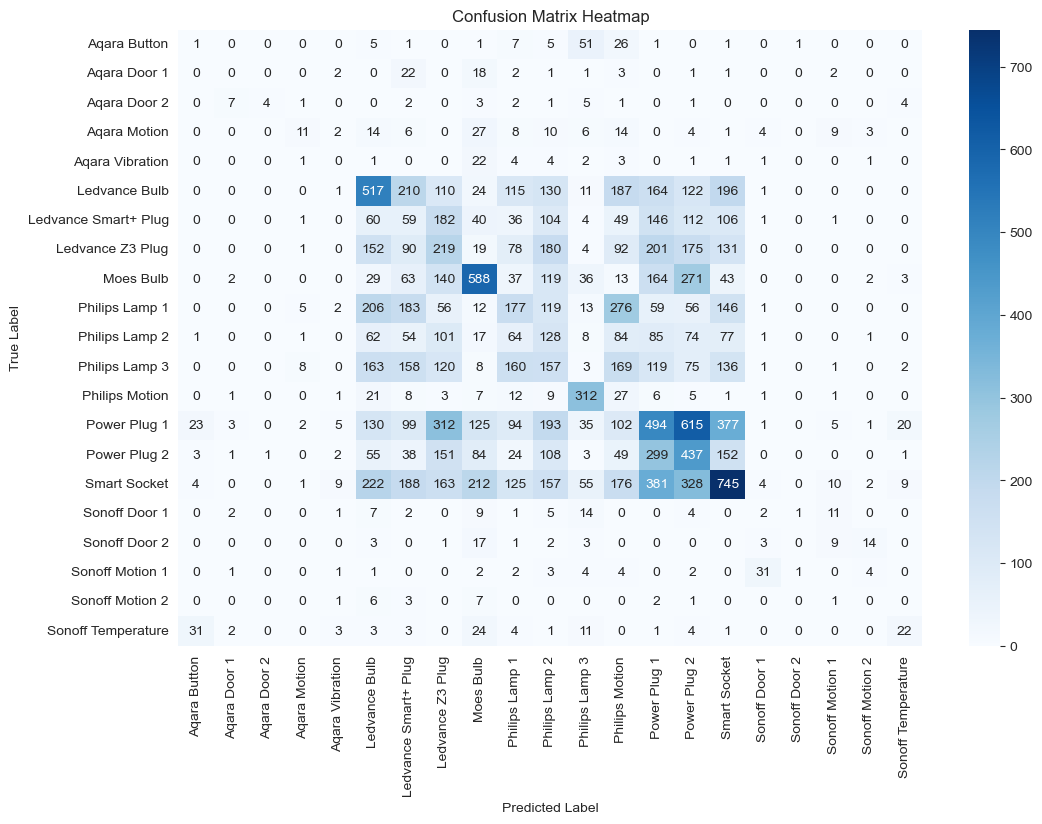

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    9078
0    6647
3     611
2     196
5     110
1     100
6      41
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.61      0.65      0.63      5219
      Button       0.20      0.03      0.06        30
        Door       0.46      0.42      0.44       112
      Motion       0.56      0.40      0.47       254
      Socket       0.69      0.66      0.68      6214
 Temperature       0.28      0.50      0.36        38
   Vibration       0.00      0.00      0.00        32

    accuracy                           0.65     11899
   macro avg       0.40      0.38      0.38     11899
weighted avg       0.65      0.65      0.65     11899

Macro F1-Score: 0.3760


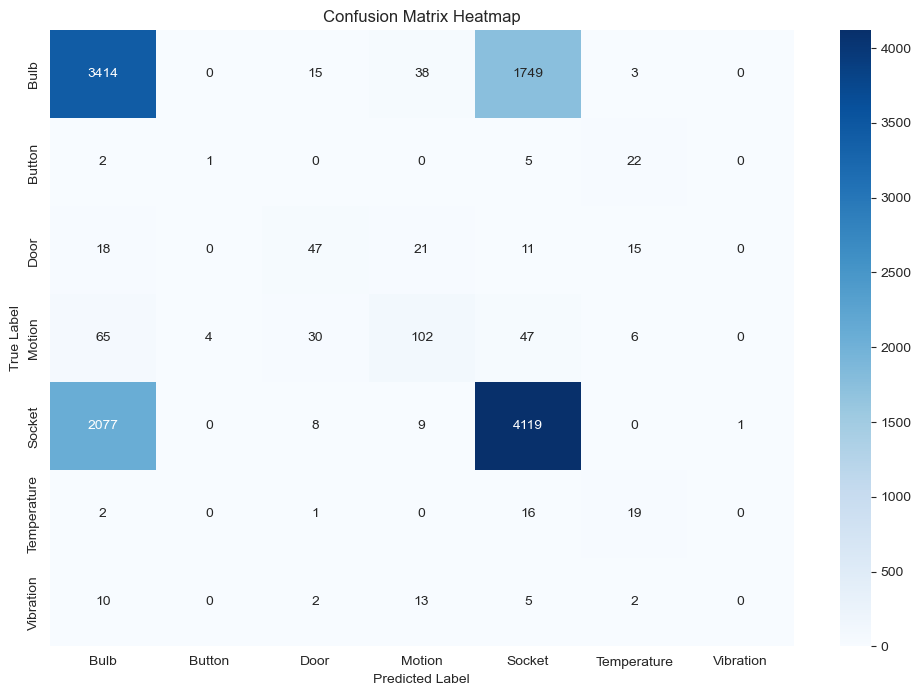

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    2791
13    2636
5     1788
8     1510
14    1408
7     1342
9     1311
11    1280
6      901
10     758
12     415
3      119
20     110
0      100
16      59
18      56
1       53
17      53
4       41
2       31
19      21
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.14      0.03      0.05        30
        Aqara Door 1       0.00      0.00      0.00        40
        Aqara Door 2       0.37      0.65      0.47        34
        Aqara Motion       0.19      0.13      0.15        31
     Aqara Vibration       0.00      0.00      0.00        32
       Ledvance Bulb       0.32      0.37      0.34      1355
Ledvance Smart+ Plug       0.11      0.06      0.08      1041
    Ledvance Z3 Plug       0.14      0.13      0.14       829
           Moes Bulb       0.56      0.61      0.59      1156
      Philips Lamp 1       0.16      0.24      0.19       852
      Philips Lamp 2       0.12      

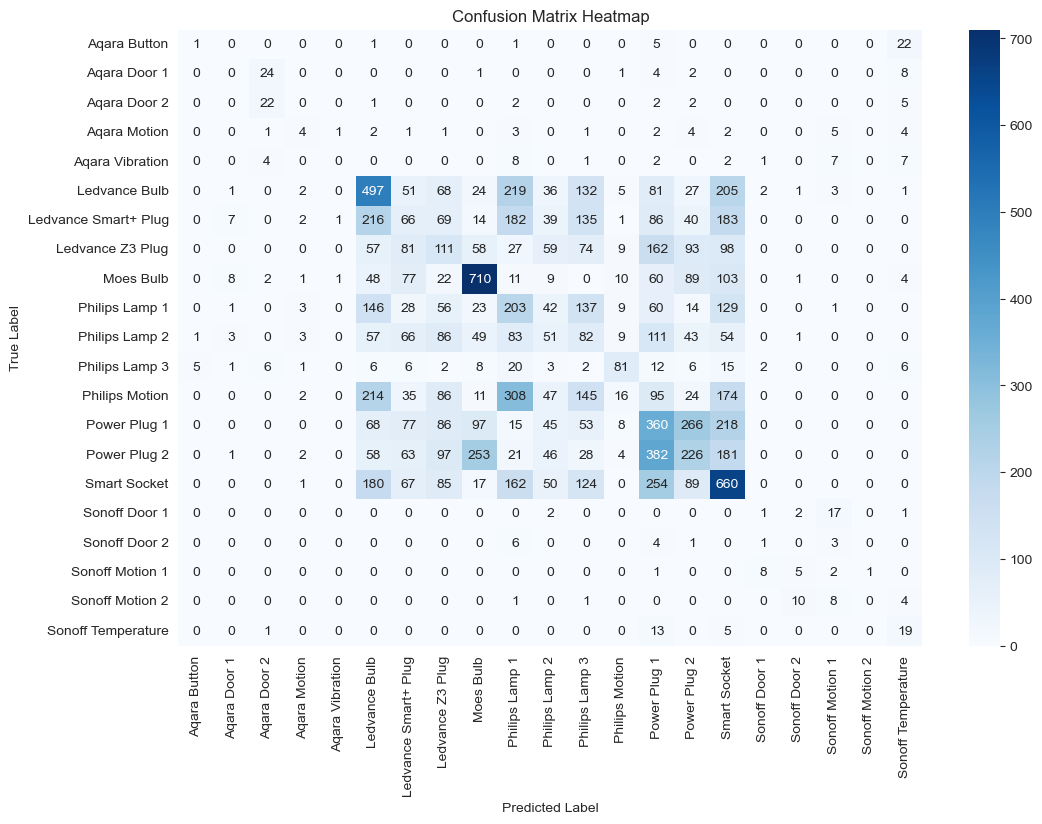

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_B_fix_duration.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/B_6-Merged_sequence_data_fix_durations/Topology_A_fix_duration.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
